# DCM labelling of DCM-TM iPSCs

This notebook calculates the correlation between RNA-seq and DCM labeling data from iPSCs (two clones, C4 and C6), and performs differential DCM methylation (DDM) analysis between uninduced and doxycycline-induced conditions.

## Input

- DCM scores per gene, available from GEO (GSE304236_DCMscores.tsv)
- RNA expression in TPM, available from GEO (GSE304232_iPSCs.RNA-seq.TPMs.txt)

## Output

- Figure 1c. Scatter plot comparing RNA-seq and DCM scores
- Figure S2a. Scatter plots of DCM scores in iPSC clones
- Figure S2g. DDM genes between -dox vs +dox
- Figure S2h. RNA-seq levels of DDM genes

## Packages

In [1]:
# General
from pathlib import Path
import numpy as np
import pandas as pd

# Plotting
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Statistics
import scipy

# Rpy2
%load_ext rpy2.ipython

# Plot settings
plt.rcParams.update({"figure.figsize": (10, 10), "svg.fonttype": "none", "font.family": "Arial"})
sns.set_style("ticks")

In [2]:
# Directories: update these paths as needed
input_dir = "../Input/GEO"   # folder where GEO data is stored
output_dir = "../Output"    # folder where output files will be saved
Path(output_dir).mkdir(parents=True, exist_ok=True)

# Settings
labels = ["iPSC", "DE", "PGT"]              # custom labels
colors = ["#264653", "#E9C46A", "#E76F51"]  # colors to use
palette = dict(zip(labels, colors))         # palette for plots

## Figure 1c. Scatter plot comparing RNA-seq and DCM scores

In [3]:
tpm = pd.read_csv(f"{input_dir}/GSE304232_iPSCs.RNA-seq.TPMs.txt", sep="\t", header=0, index_col=None)
tpm["RNA_dox"] = tpm[[f"iPSCs.dox.{i}" for i in (1,2,3)]].mean(axis=1)
tpm["RNA_nodox"] = tpm[[f"iPSCs.nodox.{i}" for i in (1,2,3)]].mean(axis=1)
tpm = tpm[~tpm["GeneName"].isna()]
tpm = tpm[~tpm["GeneName"].str.startswith(("Gm", "GM", "Rpl", "RPL", "Rps", "RPS", "ENS", "MT"))]
tpm.index = tpm["GeneID"]

dcm = pd.read_csv(f"{input_dir}/GSE304236_DCMscores.genes.txt", sep="\t", index_col=0, header=0)
dcm = dcm[['C4_nodox', 'C4_dox', 'C6_nodox', 'C6_dox', 'NrSites']]
dcm = dcm[dcm["NrSites"] > 10]

all_counts = dcm.merge(tpm, left_index=True, right_index=True)
display(all_counts)

,C4_nodox,C4_dox,C6_nodox,C6_dox,NrSites,GeneID,GeneName,iPSCs.dox.1,iPSCs.dox.2,iPSCs.dox.3,iPSCs.nodox.1,iPSCs.nodox.2,iPSCs.nodox.3,RNA_dox,RNA_nodox
GeneID,,,,,,,,,,,,,,,
ENSG00000000003,0.001749,0.043589,0.000481,0.053180,38,ENSG00000000003,TSPAN6,74.004824,83.240564,72.981576,75.525996,79.787709,98.590221,76.742321,84.634642
ENSG00000000005,0.000192,0.037994,0.000707,0.032142,41,ENSG00000000005,TNMD,7.641149,8.301945,7.992333,5.979979,7.032741,8.623295,7.978475,7.212005
ENSG00000000419,0.003835,0.091302,0.003434,0.084973,85,ENSG00000000419,DPM1,15.595583,17.665683,14.525684,19.159745,19.875700,21.465872,15.928983,20.167106
ENSG00000000457,0.002284,0.051596,0.002984,0.046855,124,ENSG00000000457,SCYL3,3.186841,3.500212,3.026082,4.129618,3.038731,3.510329,3.237712,3.559559
ENSG00000000460,0.002041,0.039393,0.002176,0.038281,562,ENSG00000000460,C1orf112,15.306726,16.872584,15.437452,18.292900,18.529346,20.055165,15.872254,18.959137
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000291263,0.030462,0.106298,0.023353,0.113405,14,ENSG00000291263,SMG1P7,3.218879,3.918667,5.399736,2.599816,2.230872,3.534777,4.179094,2.788489
ENSG00000291266,0.003913,0.091575,0.003015,0.080039,222,ENSG00000291266,SMG1P5,0.111565,0.260916,0.154375,0.000000,0.129757,0.000000,0.175619,0.043252
ENSG00000291280,0.003110,0.018238,0.003550,0.022691,105,ENSG00000291280,ANKRD20A11P,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [4]:
corr_nodox, pval_nodox = scipy.stats.spearmanr(all_counts["C4_nodox"], all_counts["RNA_nodox"])
corr_dox, pval_dox = scipy.stats.spearmanr(all_counts["C4_dox"], all_counts["RNA_dox"])

print("Spearman correlation -dox:", corr_nodox)
print("Spearman correlation +dox:", corr_dox)

Spearman correlation -dox: 0.15224490593411602
Spearman correlation +dox: 0.6001272187901103


/home/beatrice/.local/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/beatrice/.local/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


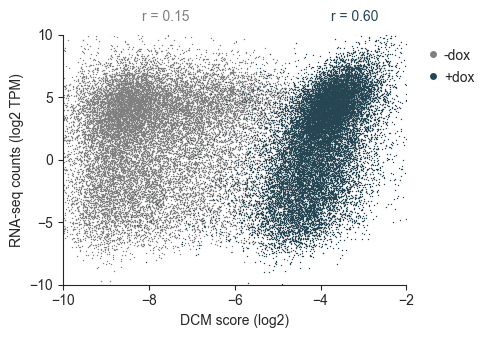

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(5,3.5))

# Scatterplot
sns.scatterplot(x=np.log2(all_counts["C4_nodox"]), y=np.log2(all_counts["RNA_nodox"]), 
                ax=ax, linewidth=0, s=1, color="gray", label="-dox")
sns.scatterplot(x=np.log2(all_counts["C4_dox"]), y=np.log2(all_counts["RNA_dox"]), 
                ax=ax, linewidth=0, s=1, color="#264653", label="+dox")

# Set axes and legends
ax.set(xlim=(-10,-2), ylim=(-10,10), xlabel="DCM score (log2)", ylabel="RNA-seq counts (log2 TPM)",
      yticks=[-10, -5, 0, 5, 10], xticks=[-10, -8, -6, -4, -2])   
ax.legend(frameon=False, bbox_to_anchor=(1, 1), loc="upper left", markerscale=5, handletextpad=-0.2, handleheight=1.3)

# Add correlation coefficient
plt.annotate(f"r = {corr_dox:.2f}", (0,0), (0.85, 1.1), color="#264653", fontsize=10,
             xycoords="axes fraction", textcoords="axes fraction", va="top", horizontalalignment="center") 
plt.annotate(f"r = {corr_nodox:.2f}", (0,0), (0.3, 1.1), color="gray", fontsize=10,
             xycoords="axes fraction", textcoords="axes fraction", va="top", horizontalalignment="center") 

sns.despine()
plt.tight_layout()
plt.savefig(f"{output_dir}/Figure1c.svg", format="svg", bbox_inches="tight")
plt.show()

## Figure S2a. Scatter plots of DCM scores in iPSC clones

In [6]:
dcm.sort_values("C4_dox", inplace=True, ascending=False)
dcm["DCM category"] = pd.qcut(dcm["C4_dox"], q=3, labels=["Low", "Medium", "High"])
display(dcm)

,C4_nodox,C4_dox,C6_nodox,C6_dox,NrSites,DCM category
GeneID,,,,,,
ENSG00000280441,0.489080,1.576105,0.528540,1.699693,167,High
ENSG00000278996,0.343420,1.168792,0.422574,1.175759,71,High
ENSG00000125503,0.023656,0.506412,0.023783,0.095769,294,High
ENSG00000120055,0.003012,0.452096,0.007956,0.409731,12,High
ENSG00000242125,0.002644,0.341939,0.001544,0.313664,25,High
...,...,...,...,...,...,...
ENSG00000229745,0.000000,0.000000,0.000000,0.000000,17,Low
ENSG00000229978,0.000951,0.000000,0.001014,0.007768,19,Low
ENSG00000261548,0.002042,0.000000,0.001251,0.004937,15,Low


In [7]:
corr_dox, _ = scipy.stats.spearmanr(dcm["C4_dox"], dcm["C6_dox"])
corr_C4, _ = scipy.stats.spearmanr(dcm["C4_nodox"], dcm["C4_dox"])
corr_C6, _ = scipy.stats.spearmanr(dcm["C6_nodox"], dcm["C6_dox"])

print("Spearman correlation clones +dox:", corr_dox)
print("Spearman correlation C4 -dox vs +dox:", corr_C4)
print("Spearman correlation C6 -dox vs +dox:", corr_C6)

Spearman correlation clones +dox: 0.971513625941763
Spearman correlation C4 -dox vs +dox: 0.38890161784597166
Spearman correlation C6 -dox vs +dox: 0.39834691168256287


/home/beatrice/.local/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


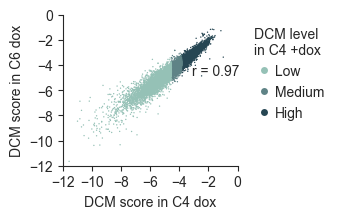

/home/beatrice/.local/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


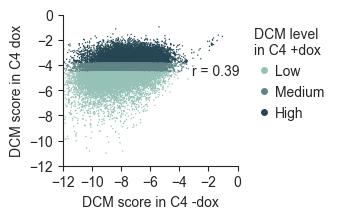

/home/beatrice/.local/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


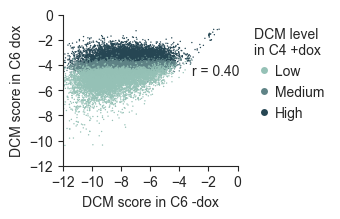

In [8]:
third_colors = ["#95c1b6", "#5f8386", "#264653"]

comparisons = [["C4_dox", "C6_dox", corr_dox, "left"], ["C4_nodox", "C4_dox", corr_C4, "center"], ["C6_nodox", "C6_dox", corr_C6, "right"]]

for x, y, corr, label in comparisons:
    plt.figure(figsize=(3.5, 2.3))

    ax = sns.scatterplot(x=np.log2(dcm[x]), y=np.log2(dcm[y]), linewidth=0, s=1,
                         hue=dcm["DCM category"], palette=third_colors, legend=True)

    ax.set(xlim=(-12, 0), ylim=(-12, 0),  xticks=[-12, -10, -8, -6, -4, -2, 0],  yticks=[-12, -10, -8, -6, -4, -2, 0],
           xlabel="DCM score in " + x.replace("_", " ").replace("no", "-"), ylabel="DCM score in " + y.replace("_", " ").replace("no", "-"))

    ax.annotate(f"r = {corr:.2f}", xy=(-1.5, -5), fontsize=10, ha="center", va="bottom")

    ax.legend(frameon=False, bbox_to_anchor=(1, 1),  loc="upper left", title="DCM level\nin C4 +dox",
        markerscale=5, handletextpad=-0.2)

    sns.despine()
    plt.tight_layout()
    plt.savefig(f"{output_dir}/SupplementalFigure2a_{label}.svg", format="svg", bbox_inches="tight")
    plt.show()

## Figure S2g. DDM genes between -dox vs +dox

In [9]:
%%R

# Set library path where packages are installed
.libPaths(c(file.path(Sys.getenv("CONDA_PREFIX"), "lib/R/library"), .libPaths()))
.libPaths()

# Load packages
packages <- c("DESeq2", "BiocParallel")
suppressMessages(invisible(lapply(packages, library, character.only = TRUE)))

# Set number of cores and memory to use
register(MulticoreParam(4))
options(future.globals.maxSize = 60000 * 1024^2, future.seed=42)
set.seed(42)

# List loaded packages
sessionInfo()

R version 4.4.0 (2024-04-24)
Platform: x86_64-conda-linux-gnu
Running under: Linux Mint 21.3

Matrix products: default
BLAS/LAPACK: /home/beatrice/miniconda3/envs/hDCM-TM/lib/libopenblasp-r0.3.25.so;  LAPACK version 3.11.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=nl_NL.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=nl_NL.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=nl_NL.UTF-8 LC_IDENTIFICATION=C       

time zone: Europe/Amsterdam
tzcode source: system (glibc)

attached base packages:
[1] stats4    tools     stats     graphics  grDevices utils     datasets 
[8] methods   base     

other attached packages:
 [1] BiocParallel_1.40.0         DESeq2_1.46.0              
 [3] SummarizedExperiment_1.36.0 Biobase_2.66.0             
 [5] MatrixGenerics_1.18.0       matrixStats_1.5.0          
 [7] GenomicRanges_1.58

In addition: There were 11 warnings (use warnings() to see them)


In [10]:
counts = pd.read_csv(f"{input_dir}/GSE304236_DCMcounts.genes.txt", sep="\t", header=0, index_col=0)
counts = counts[counts["NrSites"] > 10]
counts.index.name = None

deseq_counts = counts[["C4neg-1", "C4neg-2", "C4neg-3", "C4-1", "C4-2", "C4-3"]].copy()
display(deseq_counts)

,C4neg-1,C4neg-2,C4neg-3,C4-1,C4-2,C4-3
ENSG00000000003,1,2,4,90,65,66
ENSG00000000005,1,0,0,88,61,60
ENSG00000000419,16,14,6,485,306,267
ENSG00000000457,7,13,10,351,310,204
ENSG00000000460,43,40,42,1099,983,855
...,...,...,...,...,...,...
ENSG00000291296,7,4,2,63,28,21
ENSG00000291297,14,4,4,255,240,156
ENSG00000291299,198,107,136,1474,1019,820
ENSG00000291300,29,26,22,112,68,46


In [11]:
%%R -i deseq_counts  -o DE

meta <- data.frame(row.names = c("C4neg-1", "C4neg-2", "C4neg-3", "C4-1", "C4-2", "C4-3"),
                   Dox = factor(c(rep("NoDox", 3), rep("Dox", 3)), levels = c("NoDox", "Dox")))

dds <- DESeqDataSetFromMatrix(countData = deseq_counts, colData = meta, design = ~Dox)
dds <- DESeq(dds, fitType="local", parallel=TRUE, betaPrior=FALSE, quiet=TRUE)

# Differential test
res_diff <- results(dds, contrast=c("Dox", "Dox", "NoDox"), alpha=0.05)
res_diff <- lfcShrink(dds, contrast=c("Dox", "Dox", "NoDox"), res=res_diff, type="ashr", quiet=TRUE)

DE <- as.data.frame(res_diff)

In [12]:
de_df = DE.copy()
de_df = de_df.sort_values(by="padj")
de_df["Category"] = np.select([(de_df["padj"] < 0.05) & (de_df["log2FoldChange"] > 1) & (de_df["baseMean"] > 10)], ["DCM"], default="not significant")
de_df["-log10(adjusted P-value)"] = de_df["padj"].apply(lambda x: -np.log10(x) if x > 0 else 0)
de_df["LogBaseMean"] = np.log10(de_df["baseMean"] + 0.001)
max_value = de_df["-log10(adjusted P-value)"].replace([np.inf], np.nan).max()
de_df["-log10(adjusted P-value)"] = de_df["-log10(adjusted P-value)"].replace([np.inf], max_value)
de_df.dropna(inplace=True)
de_df = pd.merge(de_df, counts, left_index=True, right_index=True)
de_df["Category"].value_counts()

Category
not significant    30460
DCM                 4367
Name: count, dtype: int64

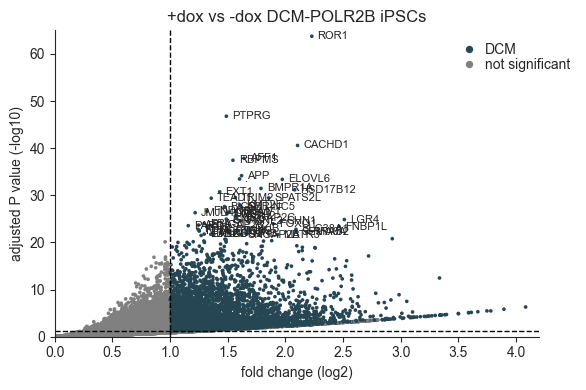

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

# Volcano plot
volcano_palette = {"DCM": palette["iPSC"], "not significant": "gray"}
sns.scatterplot(data=de_df[::-1], x="log2FoldChange", y="-log10(adjusted P-value)", hue="Category",
                marker="o", s=7, linewidth=0, legend=True, palette=volcano_palette, ax=ax)

# Add axis labels and threshold lines
ax.set(title=f"+dox vs -dox DCM-POLR2B iPSCs", xlabel="fold change (log2)", ylabel="adjusted P value (-log10)", xlim=(0, 4.2), ylim=(0, 65))
ax.axhline(-np.log10(0.05), color="black", linestyle="--", linewidth=1)
ax.axvline(1, color="black", linestyle="--", linewidth=1)

# Add labels of top 15 labeled genes
for _, r in de_df[de_df["Category"] == "DCM"].head(50).iterrows():
    ax.text(x=r["log2FoldChange"] + 0.05, y=r["-log10(adjusted P-value)"], s=r["GeneName"], fontsize=8, ha="left", va="center")

# # Add legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], loc="upper left", bbox_to_anchor=(0.8, 1), 
               title="", frameon=False, markerscale=2, handletextpad=0.2, labelspacing=0.1)

sns.despine()
plt.tight_layout()
plt.savefig(f"{output_dir}/SupplementalFigure2g.svg", format="svg")
plt.show()

## Figure S2h. RNA-seq levels of DDM genes

In [14]:
tpm["RNA"] = tpm[["RNA_dox", "RNA_nodox"]].mean(axis=1)

sign_genes = de_df[de_df["Category"] == "DCM"].index.tolist()
tpm_sign = tpm[tpm.index.isin(sign_genes)]
tpm_rand = tpm.sample(n=len(tpm_sign), random_state=0)

df_sign = tpm_sign[["RNA"]].melt(var_name="Sample", value_name="TPM")
df_sign["Group"] = "DCM-labeled genes"

df_rand = tpm_rand[["RNA"]].melt(var_name="Sample", value_name="TPM")
df_rand["Group"] = "random genes"

df_plot = pd.concat([df_rand, df_sign], ignore_index=True)
df_plot["TPM"] = np.log2(df_plot["TPM"])
display(df_plot)

stat, p = scipy.stats.mannwhitneyu(df_plot[df_plot["Group"] == "DCM-labeled genes"]["TPM"], 
                                   df_plot[df_plot["Group"] == "random genes"]["TPM"], 
                                   alternative="two-sided", nan_policy="omit")
print(p)

/home/beatrice/.local/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


,Sample,TPM,Group
0,RNA,-inf,random genes
1,RNA,6.229095,random genes
2,RNA,0.379176,random genes
3,RNA,6.016046,random genes
4,RNA,-3.021994,random genes
...,...,...,...
6901,RNA,4.715272,DCM-labeled genes
6902,RNA,3.412201,DCM-labeled genes
6903,RNA,-2.491386,DCM-labeled genes
6904,RNA,-inf,DCM-labeled genes


1.187766787075753e-303


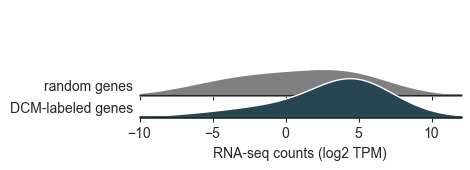

In [15]:
g = sns.FacetGrid(df_plot, row="Group", hue="Group", aspect=4, height=1, palette=["gray", palette["iPSC"]])
g.map(sns.kdeplot, "TPM", cut=0, bw_adjust=3, clip_on=False, fill=True, alpha=1, linewidth=1, edgecolor="white")

g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)

for ax in g.axes.flat:
    ax.set_ylim(0, 0.25)
g.figure.subplots_adjust(hspace=-0.75)
for ax in g.axes.flat:
    ax.set_facecolor("none")
g.set_titles("")
g.set(yticks=[], ylabel="", xlabel="RNA-seq counts (log2 TPM)", xlim=(-10, 12))
g.despine(bottom=False, left=True)

# Add labels
for ax, label in zip(g.axes.flat, df_plot["Group"].unique()):
    ax.text(-0.02, 0.1, label, ha="right", va="center", transform=ax.transAxes)

plt.savefig(f"{output_dir}/SupplementalFigure2h.svg", format="svg", bbox_inches="tight")
plt.show()